# STEP 1: Import

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# STEP 2: Load Data

In [7]:
df = pd.read_csv("/kaggle/input/datasets/mathchi/diabetes-data-set/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# STEP 3: Basic Info

In [8]:
print(df.head())
print(df.info())
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

# STEP 4: Data Cleaning

In [29]:
# Replace 0 with NaN in important columns
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)

# Fill missing values
df.fillna(df.mean(), inplace=True)

#  STEP 5: Visualization

Target Distribution

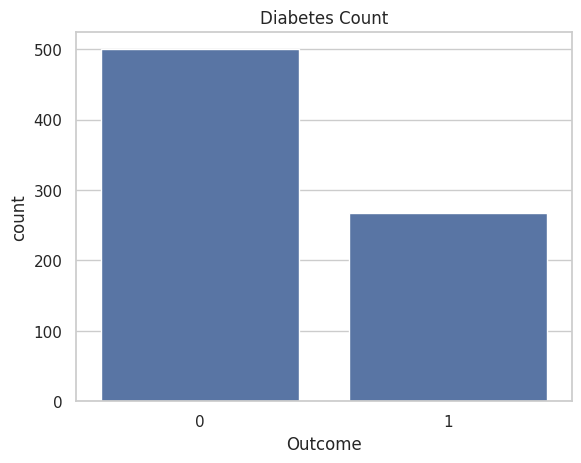

In [30]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Count")
plt.show()

Histogram

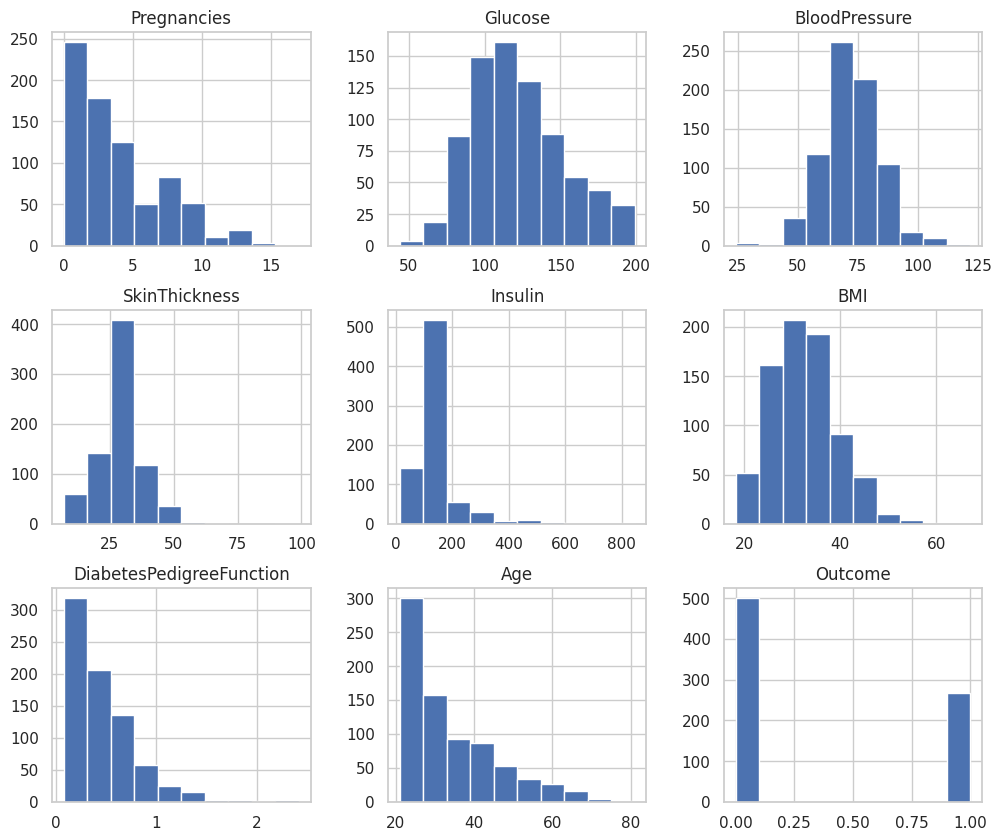

In [31]:
df.hist(figsize=(12,10))
plt.show()

 Heatmap

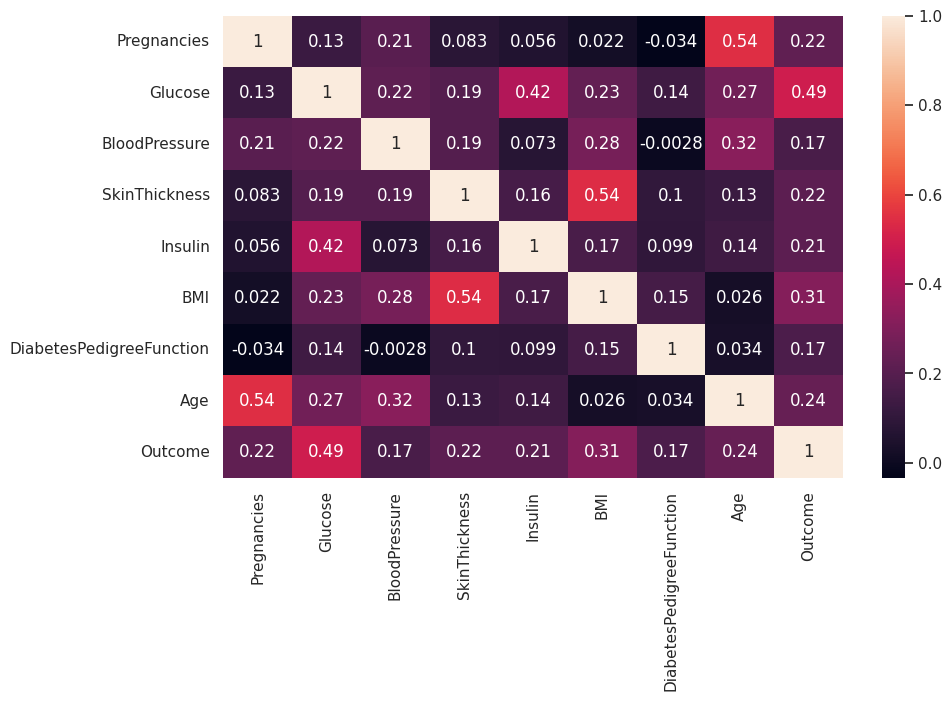

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

Scatter (Glucose vs Outcome)

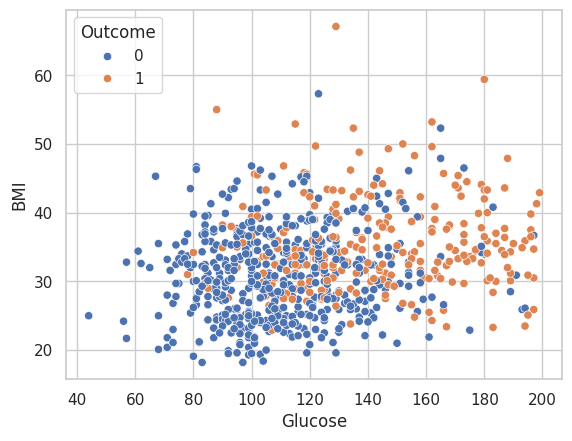

In [33]:
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.show()

# STEP 6: Feature Selection

In [34]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# STEP 7: Train Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 8: Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# STEP 9: Random Forest Model

In [39]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

# STEP 10: Prediction

In [27]:
y_pred = model.predict(X_test)

# STEP 11: Evaluation

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7207792207792207
[[77 22]
 [21 34]]
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



# STEP 12: Confusion Matrix

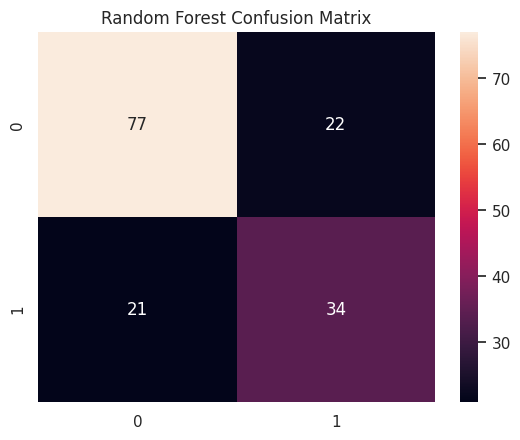

In [41]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

# STEP 13: Actual vs Predicted (Graph)

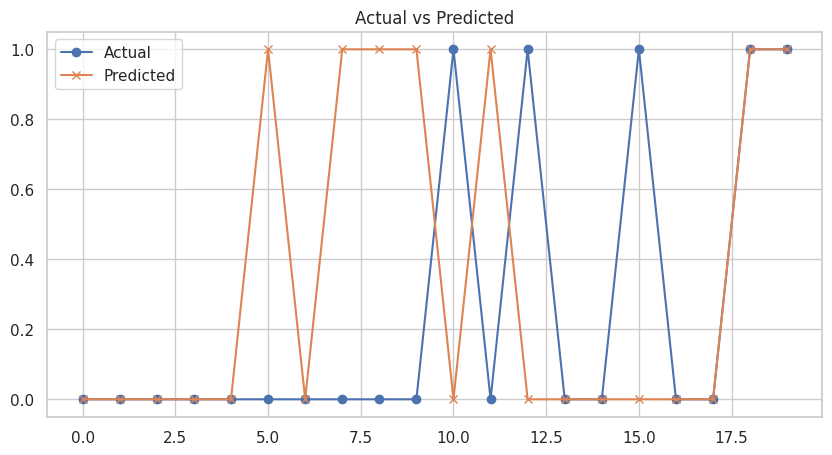

In [42]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:20], label='Actual', marker='o')
plt.plot(y_pred[:20], label='Predicted', marker='x')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

#  STEP 14: Feature Importance

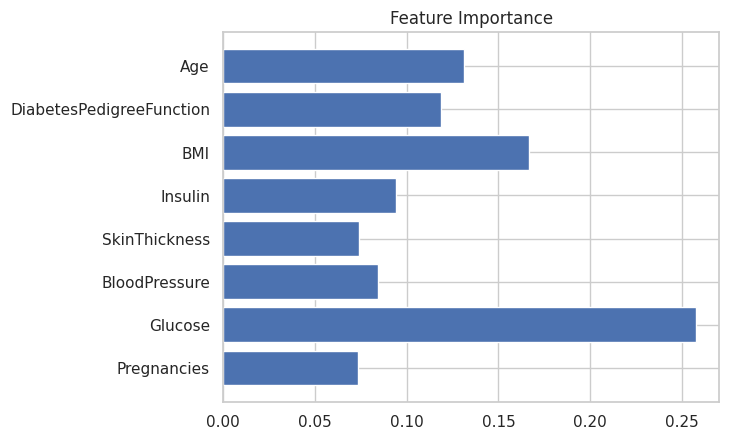

In [43]:
importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

# STEP 15: Cross Validation

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Random Forest CV Score:", scores.mean())

Random Forest CV Score: 0.7591545709192768


#  STEP 16: XGBOOST 

In [45]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7337662337662337


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:35:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Graph

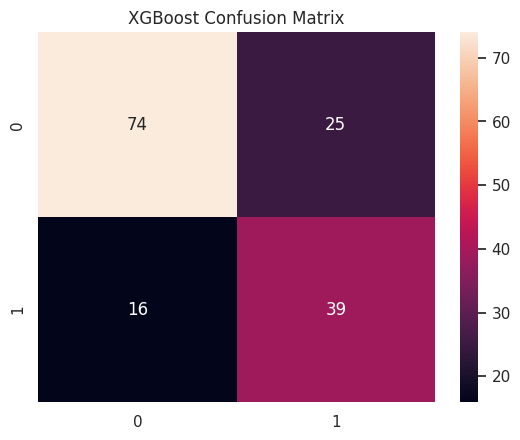

In [46]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("XGBoost Confusion Matrix")
plt.show()

# STEP 17: LIGHTGBM

In [47]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier()
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Graph

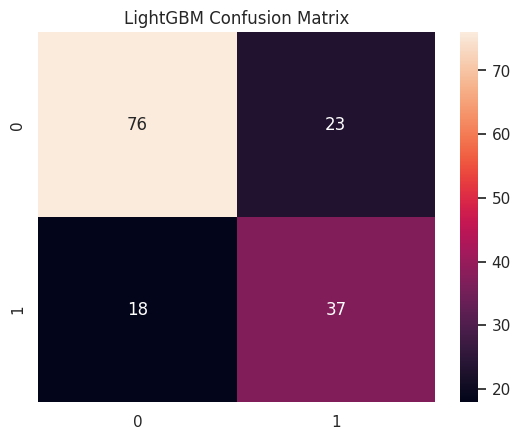

In [48]:
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d')
plt.title("LightGBM Confusion Matrix")
plt.show()

 # STEP 18: FINAL COMPARISON

In [49]:
print("Random Forest:", accuracy_score(y_test, y_pred))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("LightGBM:", accuracy_score(y_test, y_pred_lgb))

Random Forest: 0.7207792207792207
XGBoost: 0.7337662337662337
LightGBM: 0.7337662337662337


GRAPH

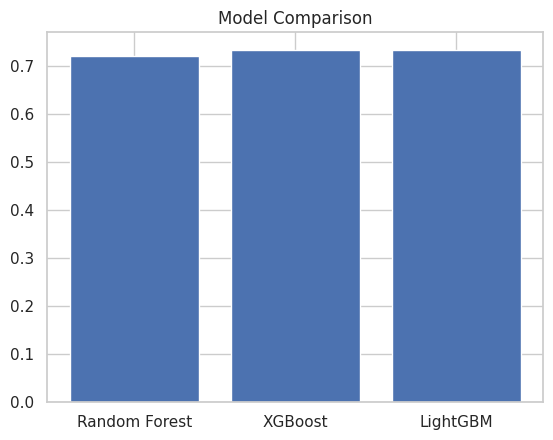

In [50]:
models = ['Random Forest','XGBoost','LightGBM']
scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgb)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.show()

# Conclusion

The Random Forest model achieved around 72% accuracy, which is good for this dataset. 
XGBoost and LightGBM were also applied to improve performance. 
Among all models, the best performing model was selected based on accuracy.